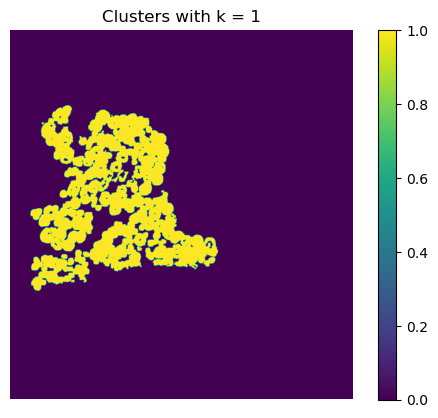

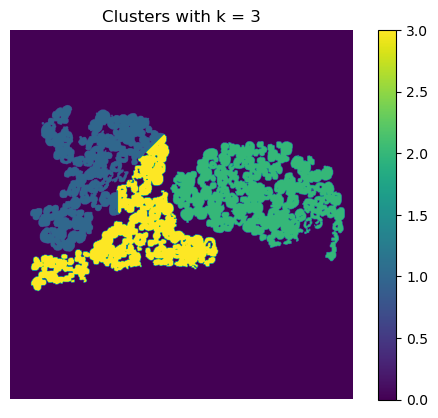

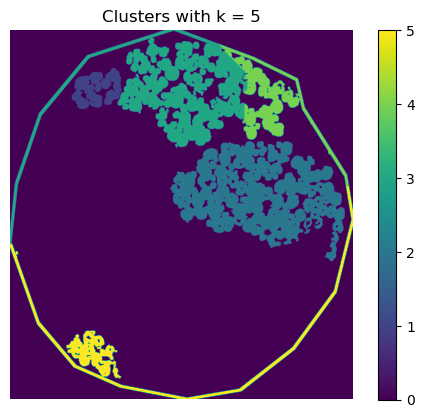

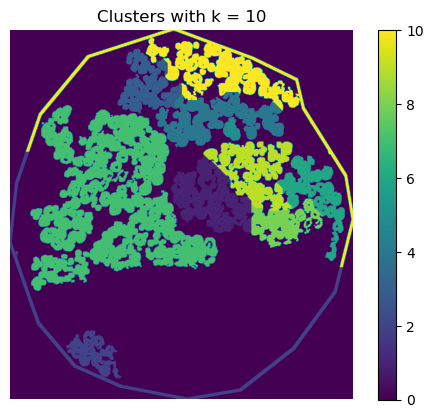

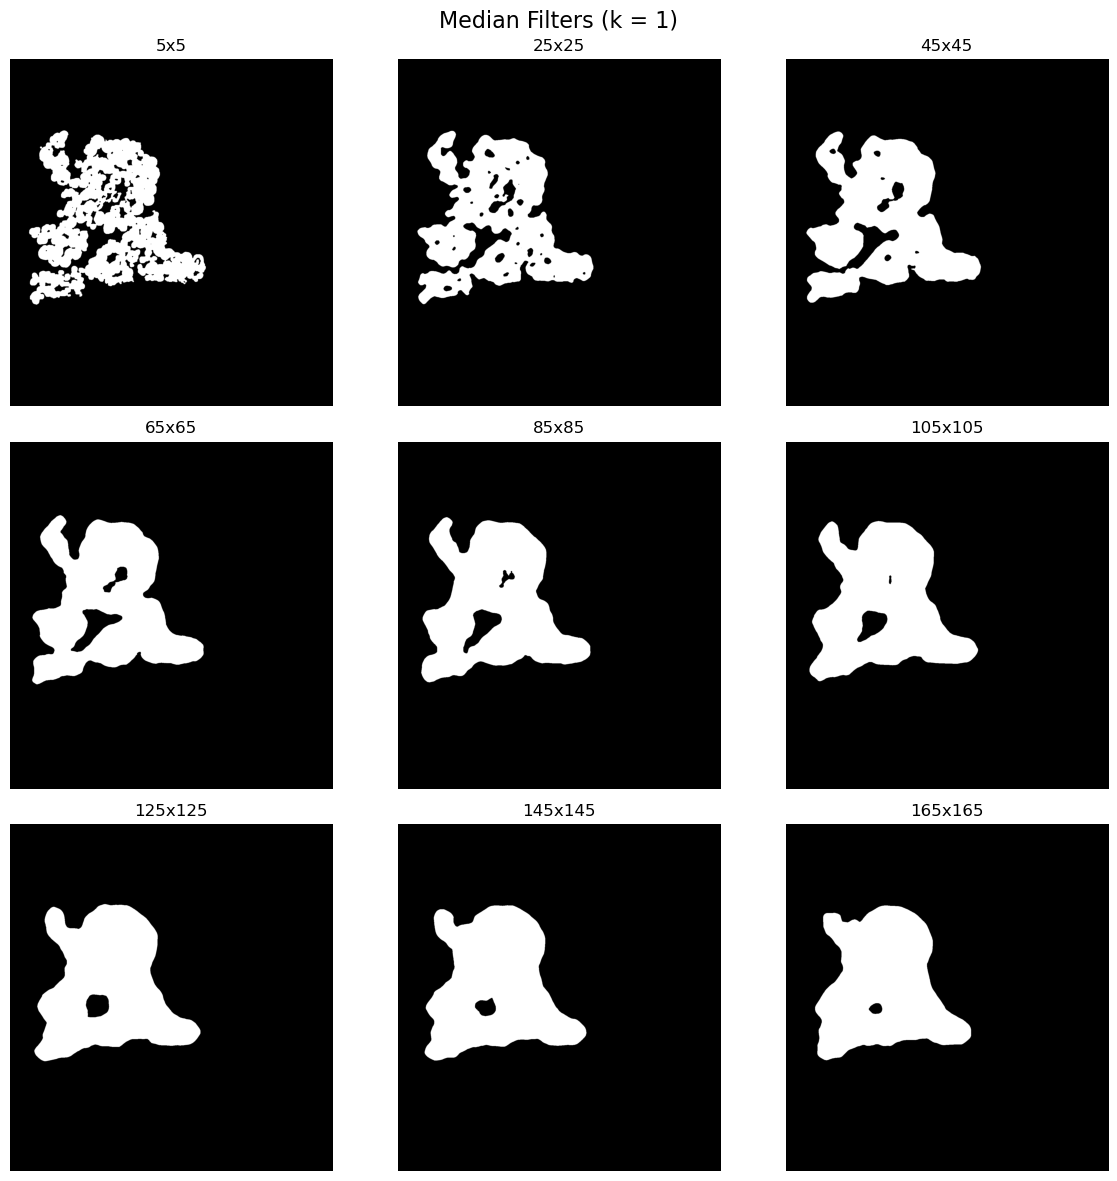

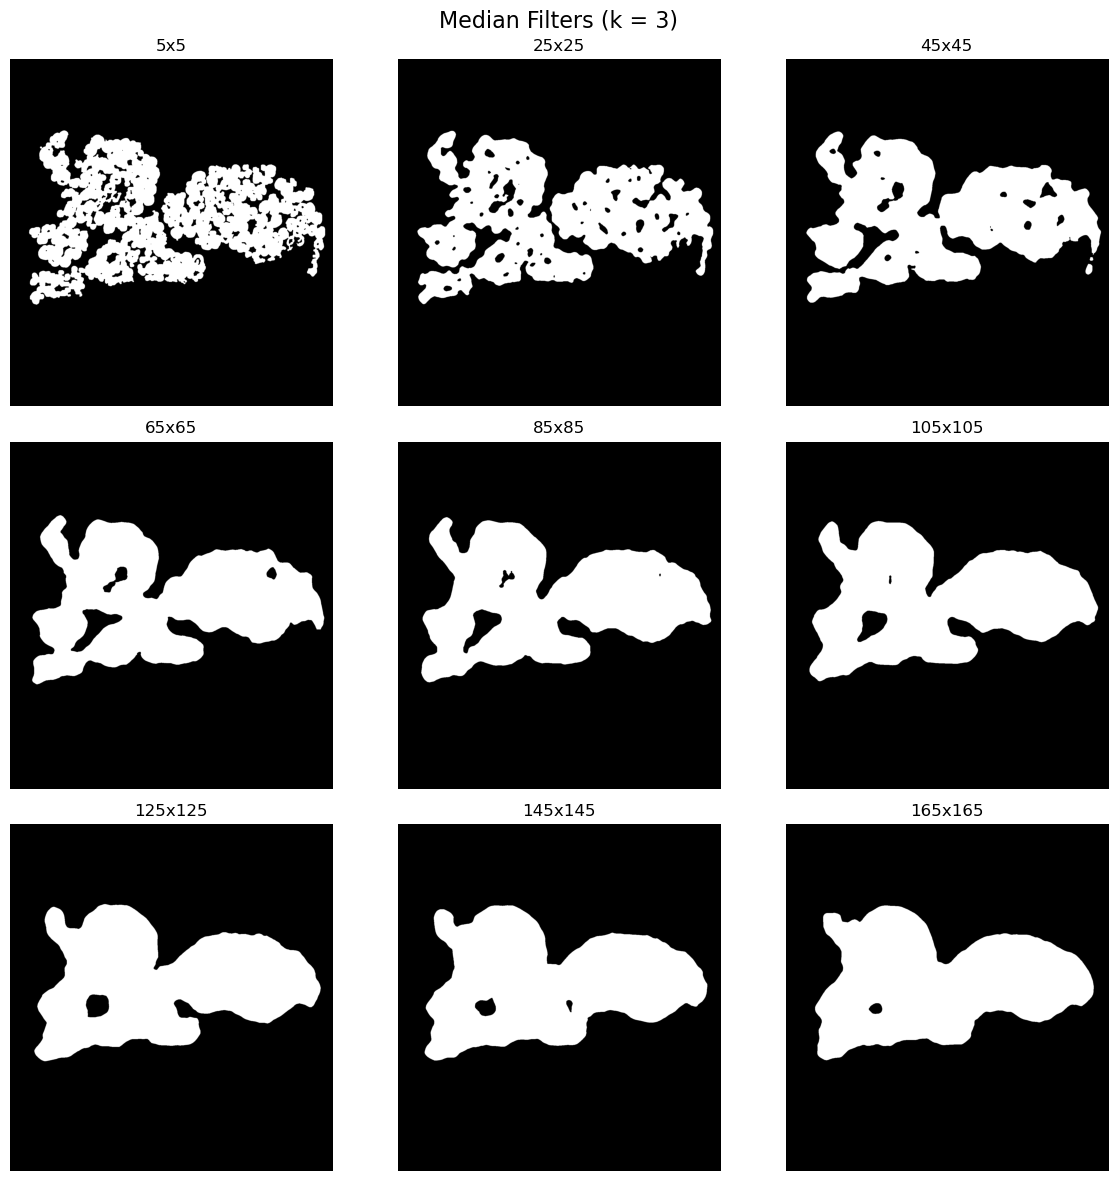

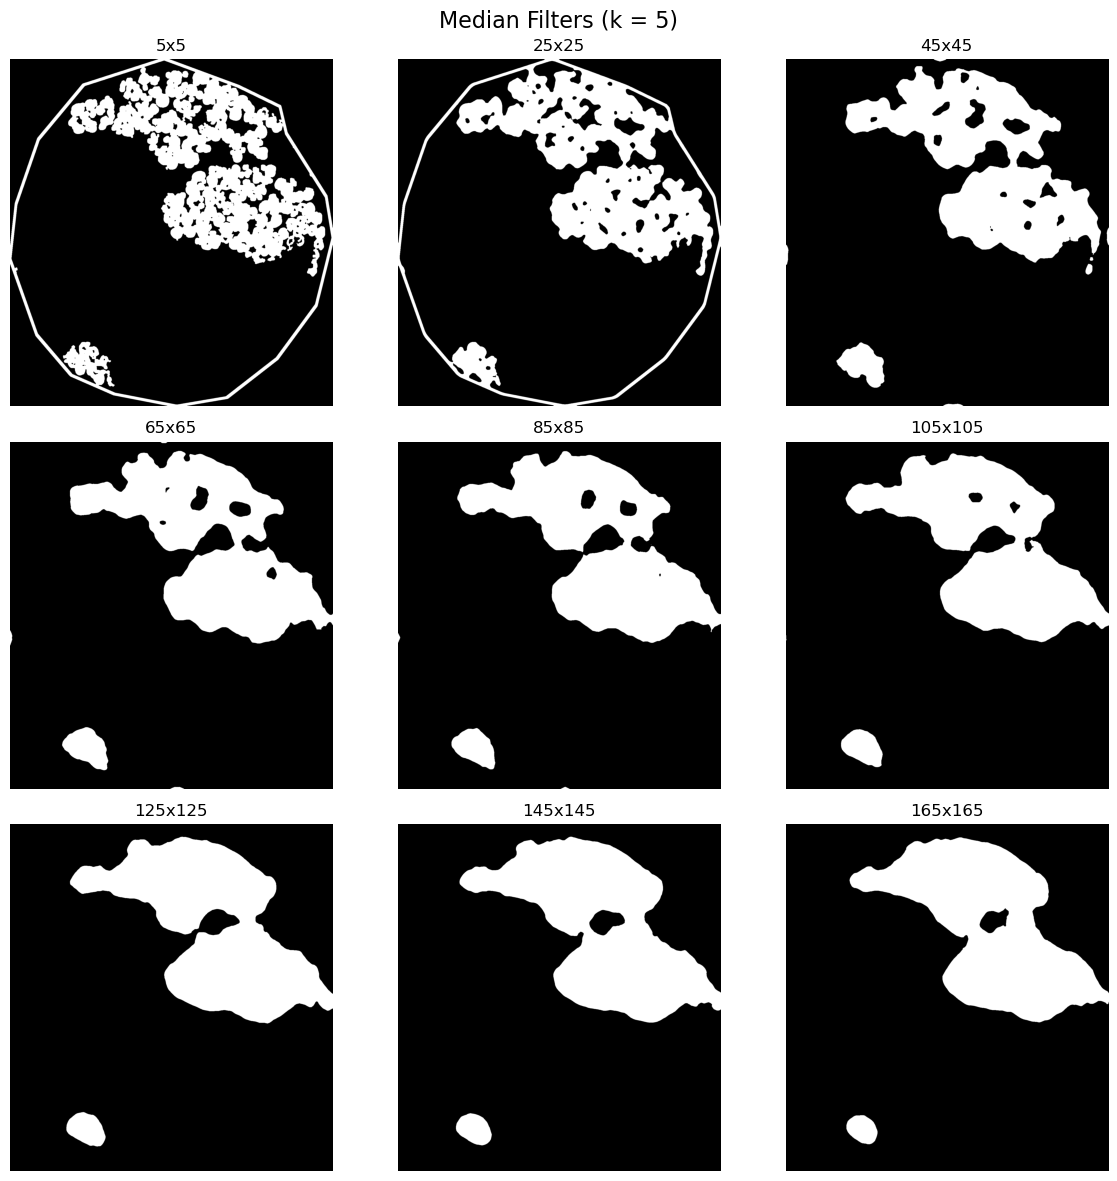

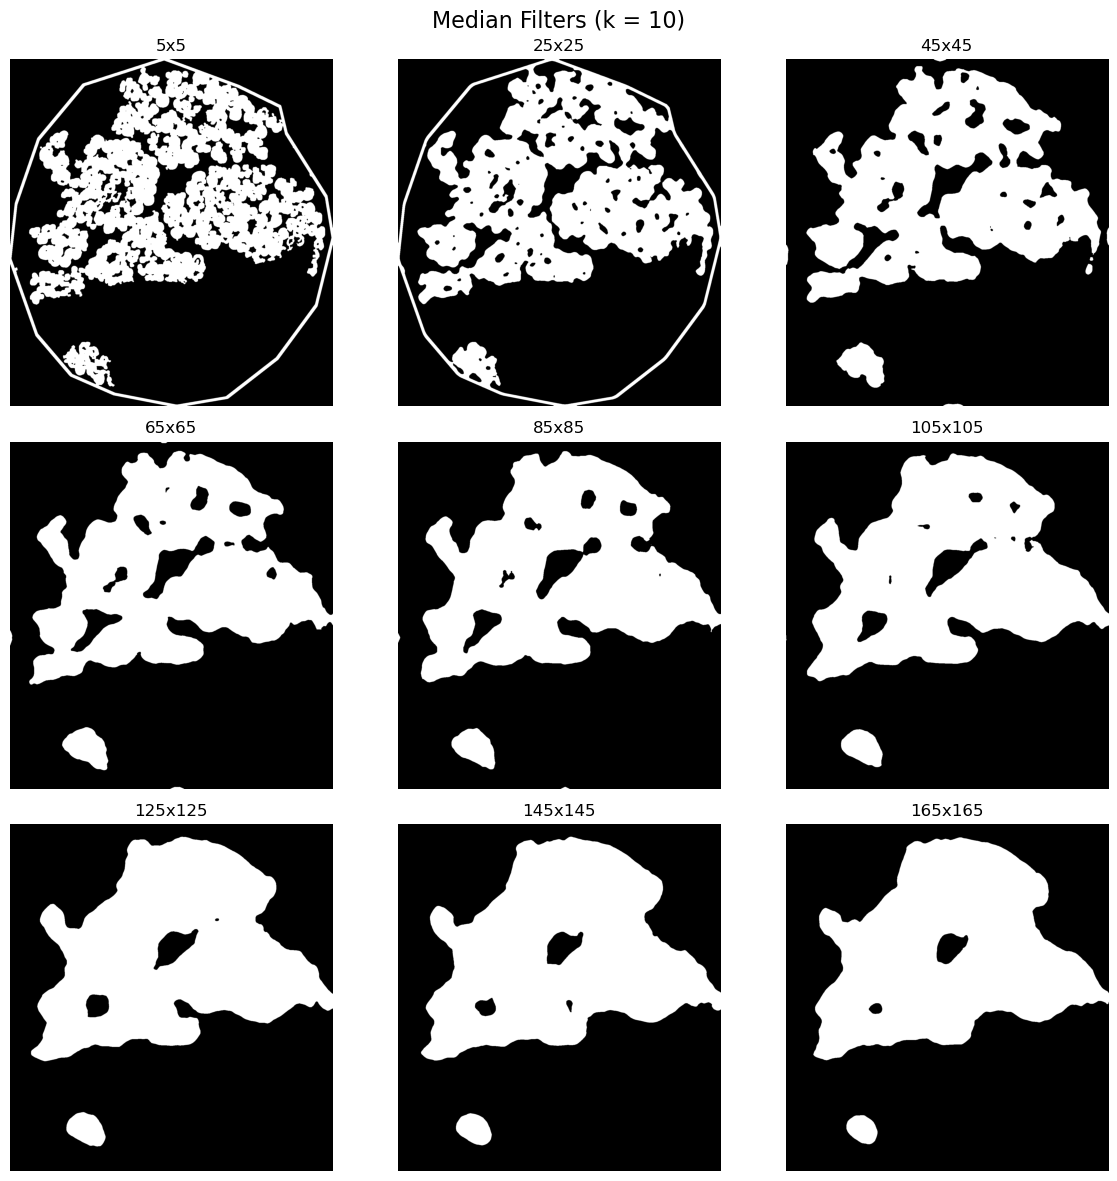

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from collections import deque

# -----------------------------
# 1. Load grayscale image
# -----------------------------
# 👉 CHANGE THIS PATH
image_path = r"C:\Users\3kp05\Downloads\blur_maps_set2_Image_01_20x_bf_05_all\4\blur_map_7x7.png"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found. Check path.")

h, w = img.shape

# -----------------------------
# 2. Condition function
# -----------------------------
def has_nonzero_neighbor(img, x, y):
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < h and 0 <= ny < w:
                if img[nx, ny] > 0:
                    return True
    return False


# -----------------------------
# 3. Multi-source clustering
# -----------------------------
def multi_source_clustering(img, seeds):
    labels = np.zeros((h, w), dtype=int)
    queue = deque()

    # Initialize seeds
    for i, (x, y) in enumerate(seeds):
        labels[x, y] = i + 1
        queue.append((x, y, i + 1))

    while queue:
        x, y, cid = queue.popleft()

        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy

                if 0 <= nx < h and 0 <= ny < w:
                    if labels[nx, ny] == 0:
                        if img[nx, ny] > 0 or has_nonzero_neighbor(img, nx, ny):
                            labels[nx, ny] = cid
                            queue.append((nx, ny, cid))

    return labels


# -----------------------------
# 4. Run for different k values
# -----------------------------
k_values = [1, 3, 5, 10]  # you can change this

nonzero_pixels = list(zip(*np.where(img > 0)))

if len(nonzero_pixels) == 0:
    raise ValueError("No non-zero pixels in image.")

results = {}

for k in k_values:
    seeds = random.sample(nonzero_pixels, min(k, len(nonzero_pixels)))
    labels = multi_source_clustering(img, seeds)
    results[k] = labels


# -----------------------------
# 5. Plot results
# -----------------------------
for k in k_values:
    plt.figure()
    plt.title(f"Clusters with k = {k}")
    plt.imshow(results[k])
    plt.colorbar()
    plt.axis("off")
    plt.show()

# -----------------------------
# 6. Binary + Median Filter Visualization
# -----------------------------
# for k in k_values:
#     labels = results[k]

#     # Convert to binary image
#     binary = np.zeros_like(labels, dtype=np.uint8)
#     binary[labels > 0] = 255   # clusters → white

#     # Apply median filter
#     median = cv2.medianBlur(binary, 75)  # kernel size must be odd (3,5,7,...)

#     # Plot side by side
#     plt.figure(figsize=(10, 4))

#     plt.subplot(1, 2, 1)
#     plt.title(f"Binary (k = {k})")
#     plt.imshow(binary, cmap='gray')
#     plt.axis("off")

#     plt.subplot(1, 2, 2)
#     plt.title(f"Median Filtered (k = {k})")
#     plt.imshow(median, cmap='gray')
#     plt.axis("off")

#     plt.show()

# -----------------------------
# 6. Binary + Multiple Median Filters Visualization
# -----------------------------
for k in k_values:
    labels = results[k]

    # Convert to binary image
    binary = np.zeros_like(labels, dtype=np.uint8)
    binary[labels > 0] = 255

    # Kernel sizes (odd only)
    kernel_sizes = list(range(5, 166, 20))  # 5, 15, 25, ..., 165

    # Layout (2 or 3 rows)
    n = len(kernel_sizes)
    rows = 3
    cols = int(np.ceil(n / rows))

    plt.figure(figsize=(4 * cols, 4 * rows))
    plt.suptitle(f"Median Filters (k = {k})", fontsize=16)

    for i, ks in enumerate(kernel_sizes):
        median = cv2.medianBlur(binary, ks)

        plt.subplot(rows, cols, i + 1)
        plt.title(f"{ks}x{ks}")
        plt.imshow(median, cmap='gray')
        plt.axis("off")

    plt.tight_layout()
    plt.show()


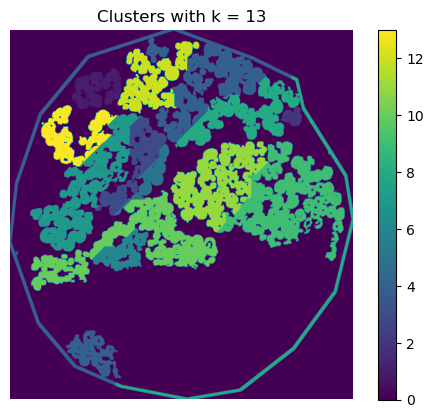

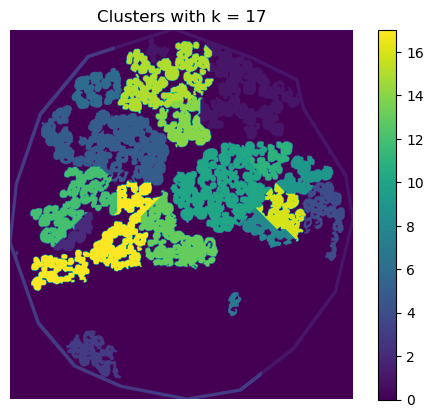

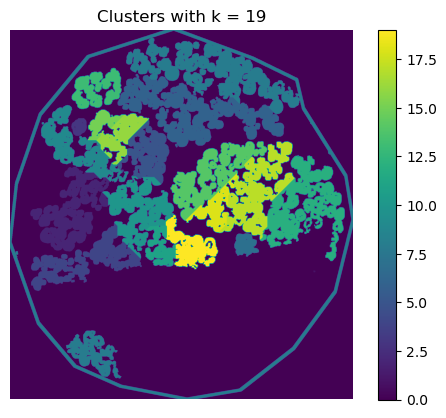

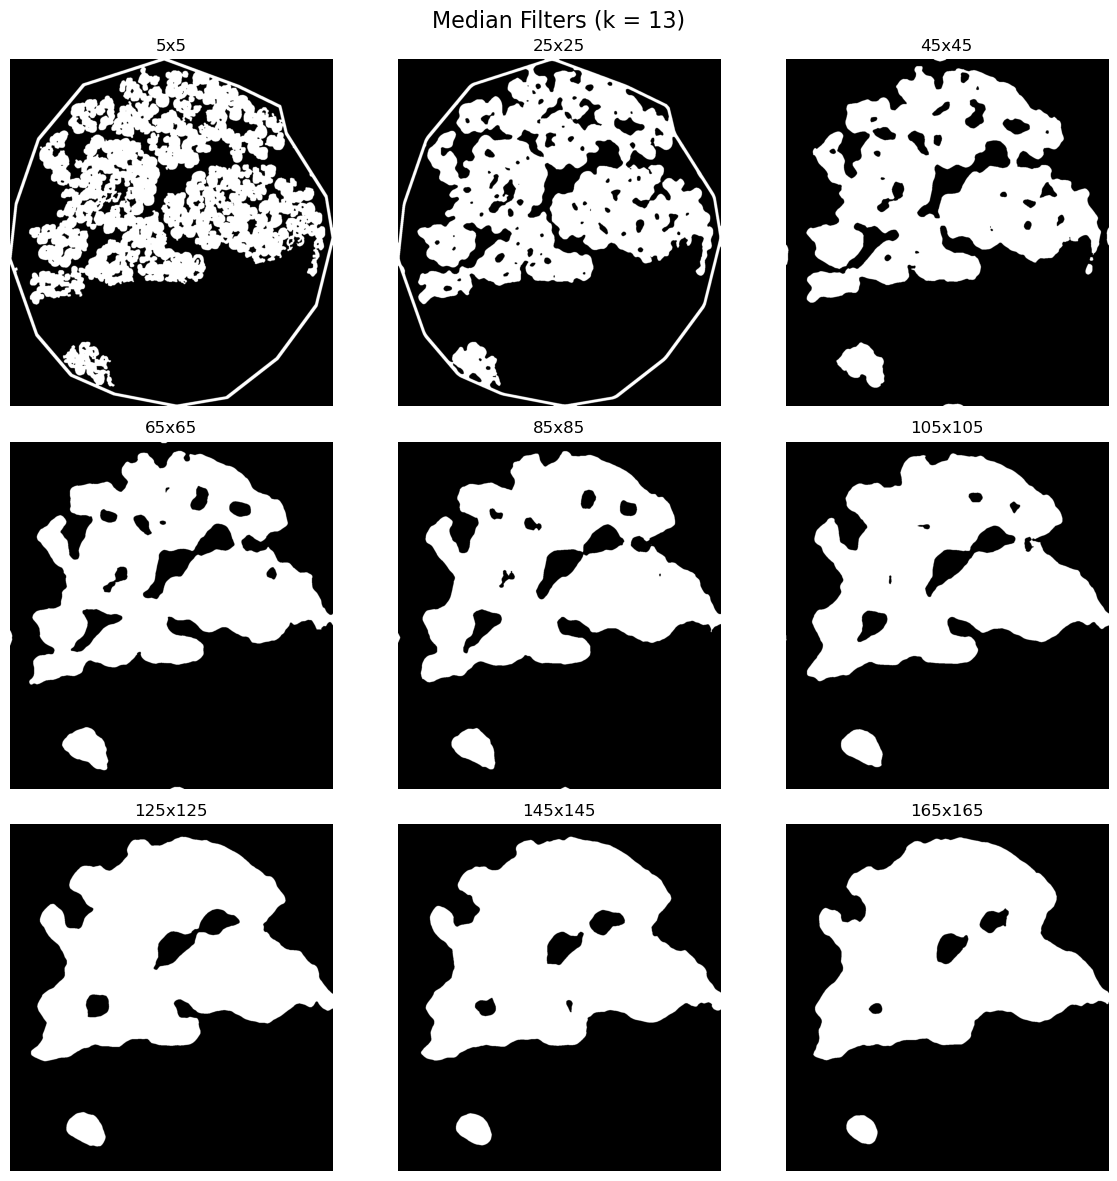

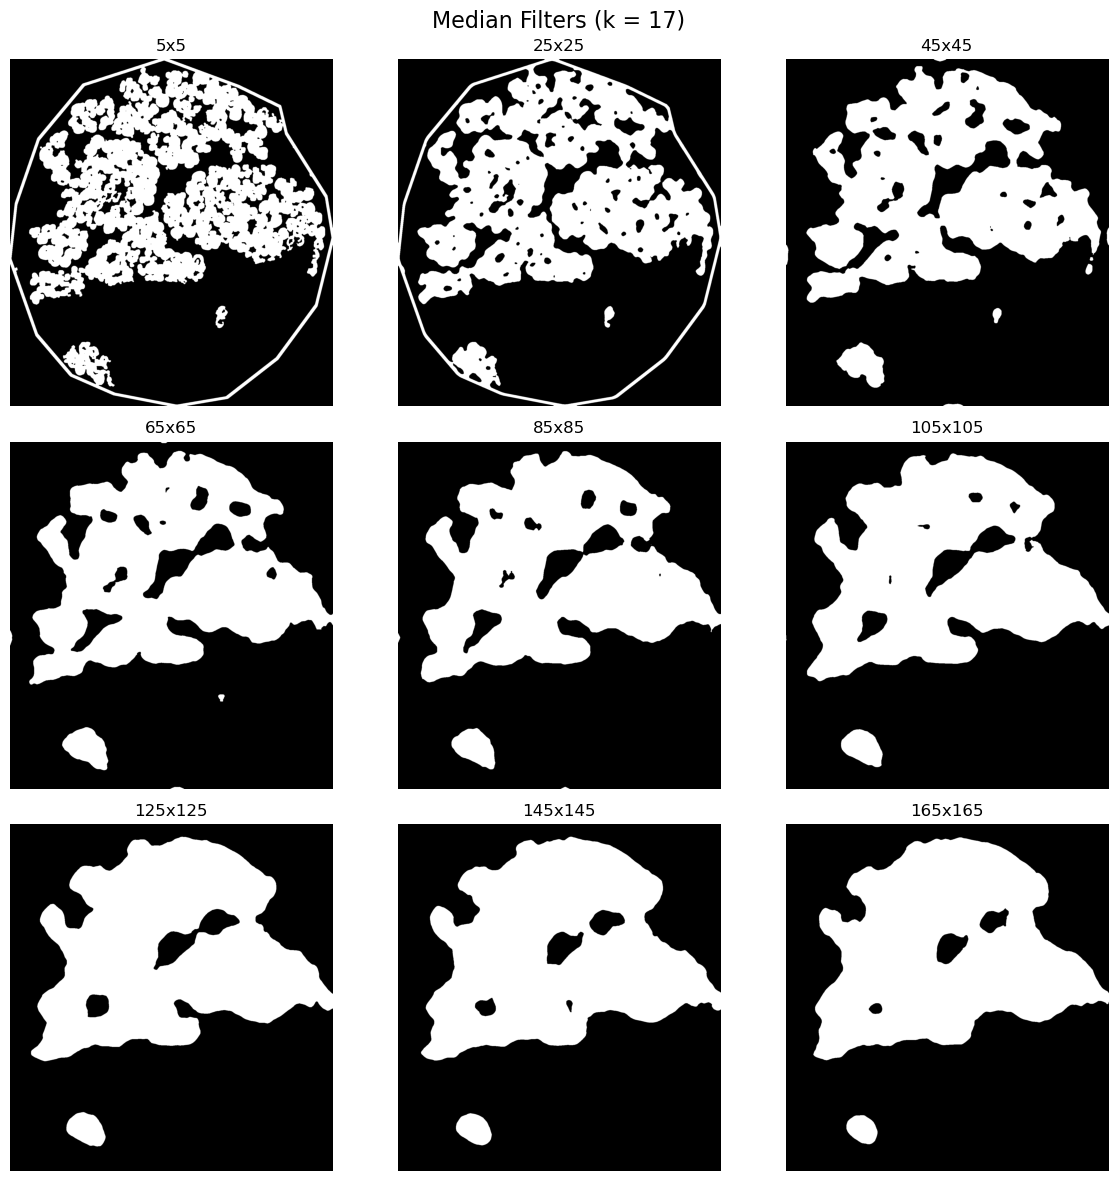

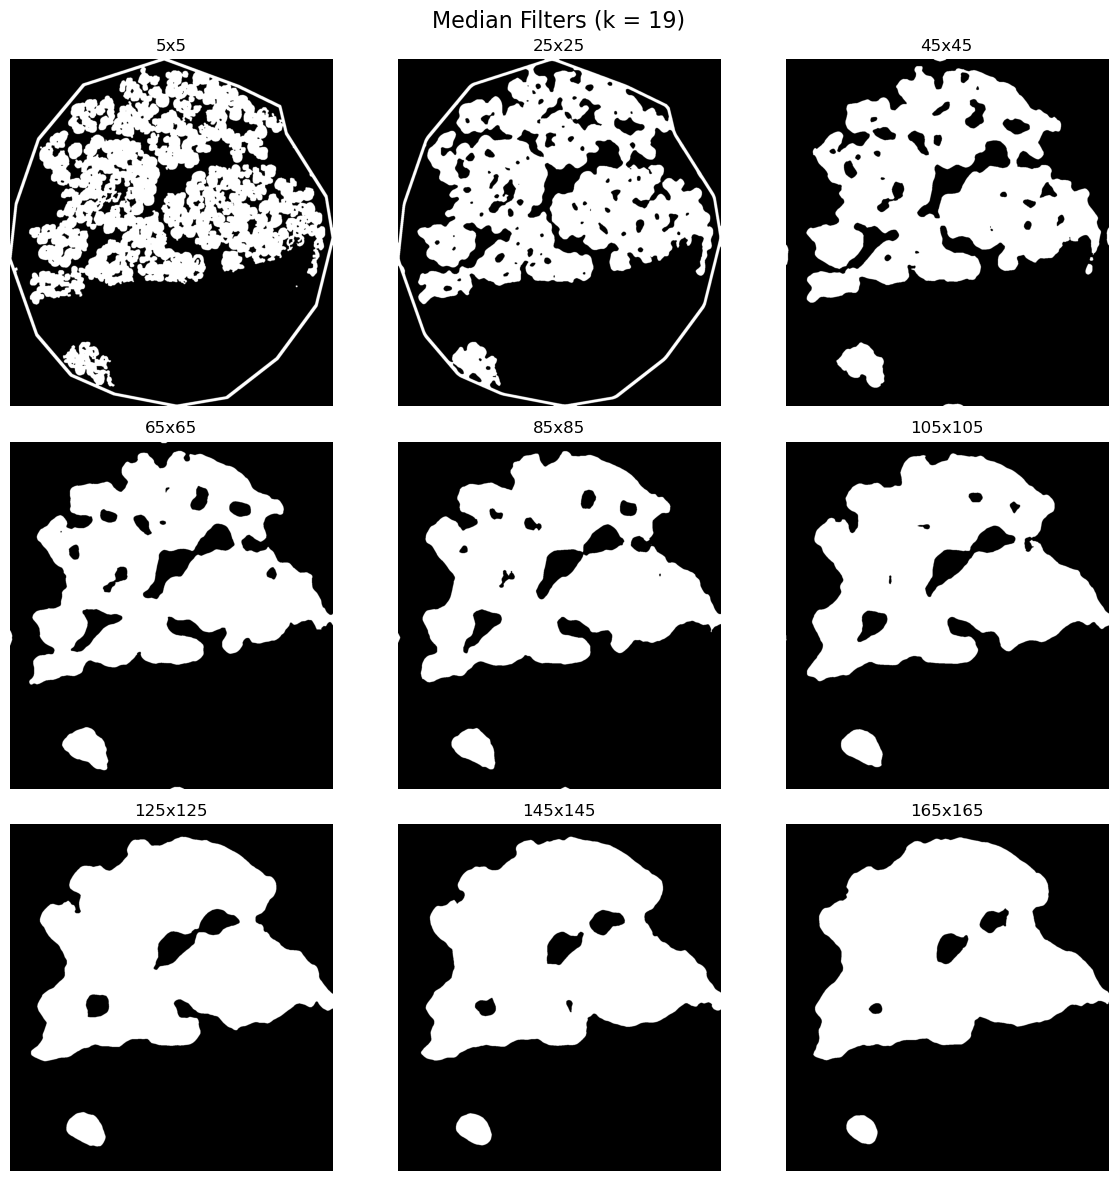

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from collections import deque

# -----------------------------
# 1. Load grayscale image
# -----------------------------
# 👉 CHANGE THIS PATH
image_path = r"C:\Users\3kp05\Downloads\blur_maps_set2_Image_01_20x_bf_05_all\4\blur_map_7x7.png"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found. Check path.")

h, w = img.shape

# -----------------------------
# 2. Condition function
# -----------------------------
def has_nonzero_neighbor(img, x, y):
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < h and 0 <= ny < w:
                if img[nx, ny] > 0:
                    return True
    return False


# -----------------------------
# 3. Multi-source clustering
# -----------------------------
def multi_source_clustering(img, seeds):
    labels = np.zeros((h, w), dtype=int)
    queue = deque()

    # Initialize seeds
    for i, (x, y) in enumerate(seeds):
        labels[x, y] = i + 1
        queue.append((x, y, i + 1))

    while queue:
        x, y, cid = queue.popleft()

        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy

                if 0 <= nx < h and 0 <= ny < w:
                    if labels[nx, ny] == 0:
                        if img[nx, ny] > 0 or has_nonzero_neighbor(img, nx, ny):
                            labels[nx, ny] = cid
                            queue.append((nx, ny, cid))

    return labels


# -----------------------------
# 4. Run for different k values
# -----------------------------
k_values = [13,17,19]  # you can change this

nonzero_pixels = list(zip(*np.where(img > 0)))

if len(nonzero_pixels) == 0:
    raise ValueError("No non-zero pixels in image.")

results = {}

for k in k_values:
    seeds = random.sample(nonzero_pixels, min(k, len(nonzero_pixels)))
    labels = multi_source_clustering(img, seeds)
    results[k] = labels


# -----------------------------
# 5. Plot results
# -----------------------------
for k in k_values:
    plt.figure()
    plt.title(f"Clusters with k = {k}")
    plt.imshow(results[k])
    plt.colorbar()
    plt.axis("off")
    plt.show()

# -----------------------------
# 6. Binary + Multiple Median Filters Visualization
# -----------------------------
for k in k_values:
    labels = results[k]

    # Convert to binary image
    binary = np.zeros_like(labels, dtype=np.uint8)
    binary[labels > 0] = 255

    # Kernel sizes (odd only)
    kernel_sizes = list(range(5, 166, 20))  # 5, 15, 25, ..., 165

    # Layout (2 or 3 rows)
    n = len(kernel_sizes)
    rows = 3
    cols = int(np.ceil(n / rows))

    plt.figure(figsize=(4 * cols, 4 * rows))
    plt.suptitle(f"Median Filters (k = {k})", fontsize=16)

    for i, ks in enumerate(kernel_sizes):
        median = cv2.medianBlur(binary, ks)

        plt.subplot(rows, cols, i + 1)
        plt.title(f"{ks}x{ks}")
        plt.imshow(median, cmap='gray')
        plt.axis("off")

    plt.tight_layout()
    plt.show()


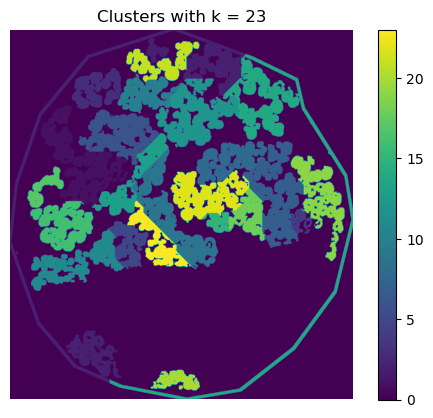

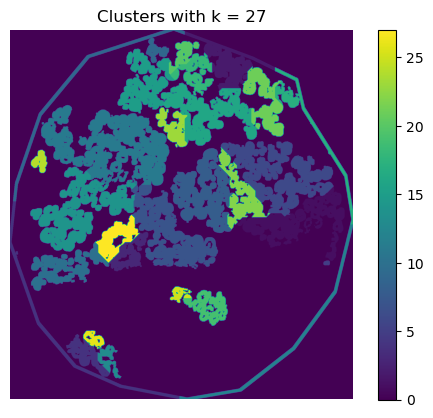

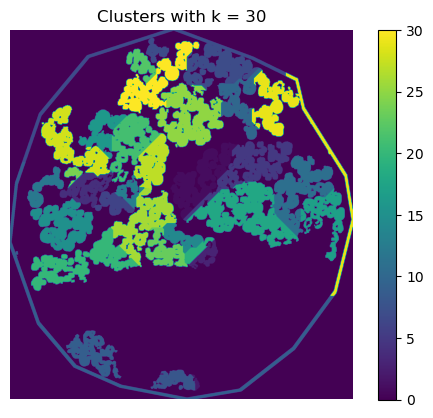

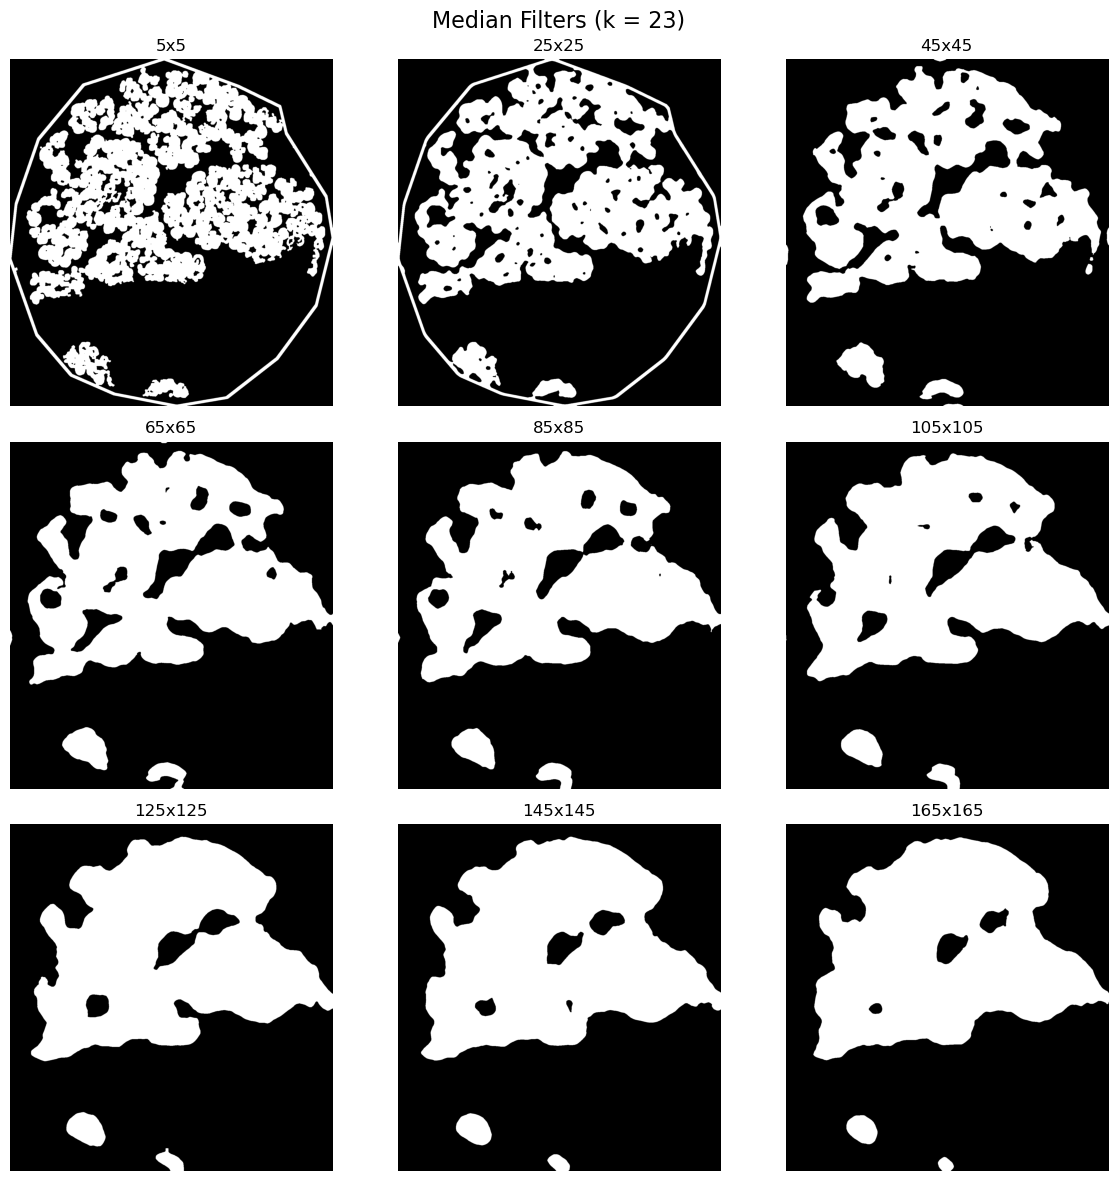

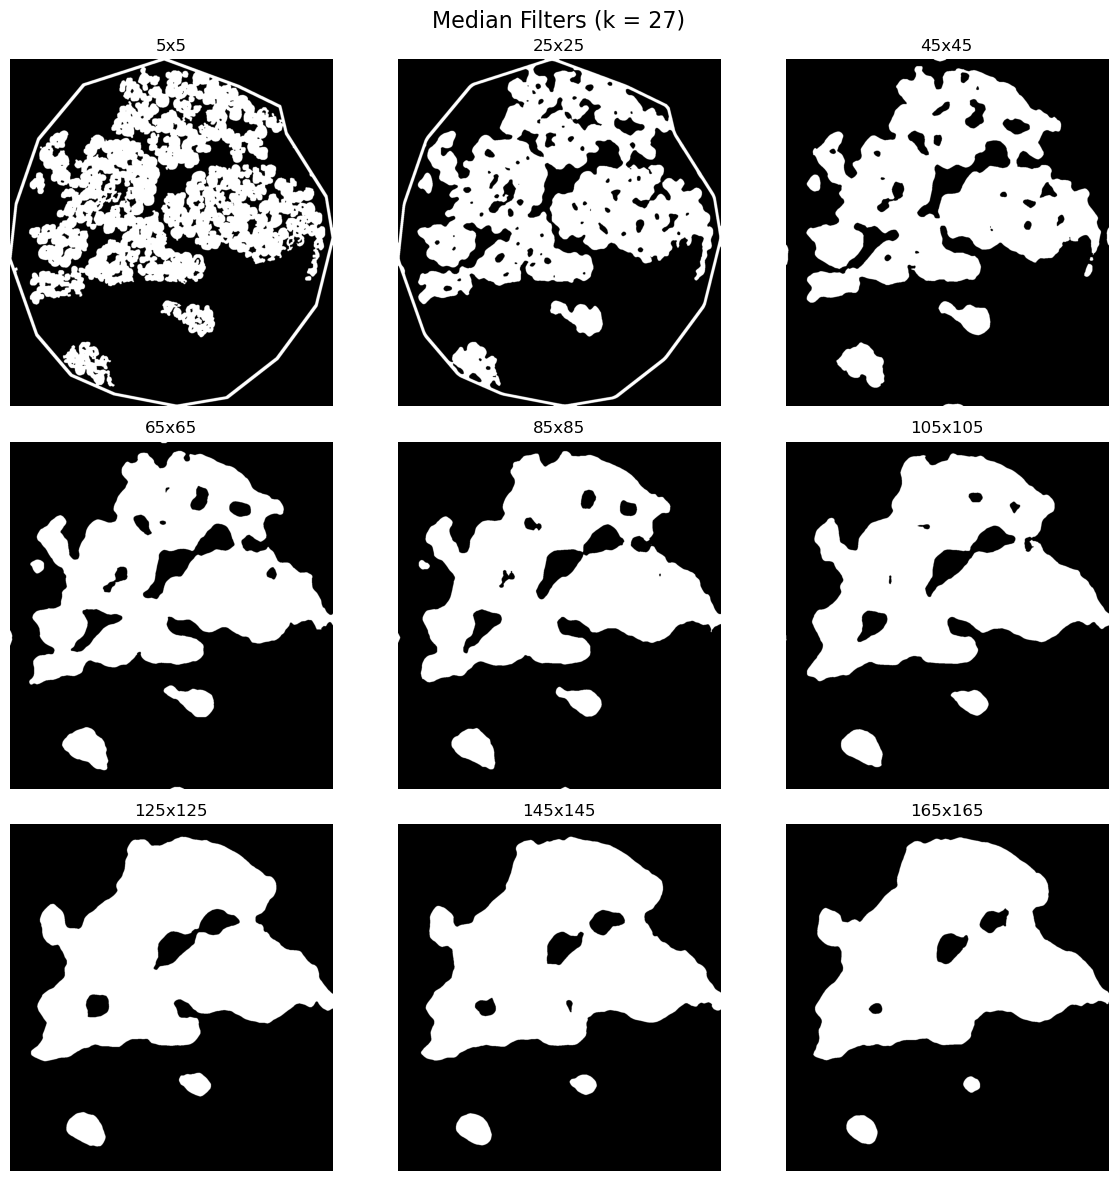

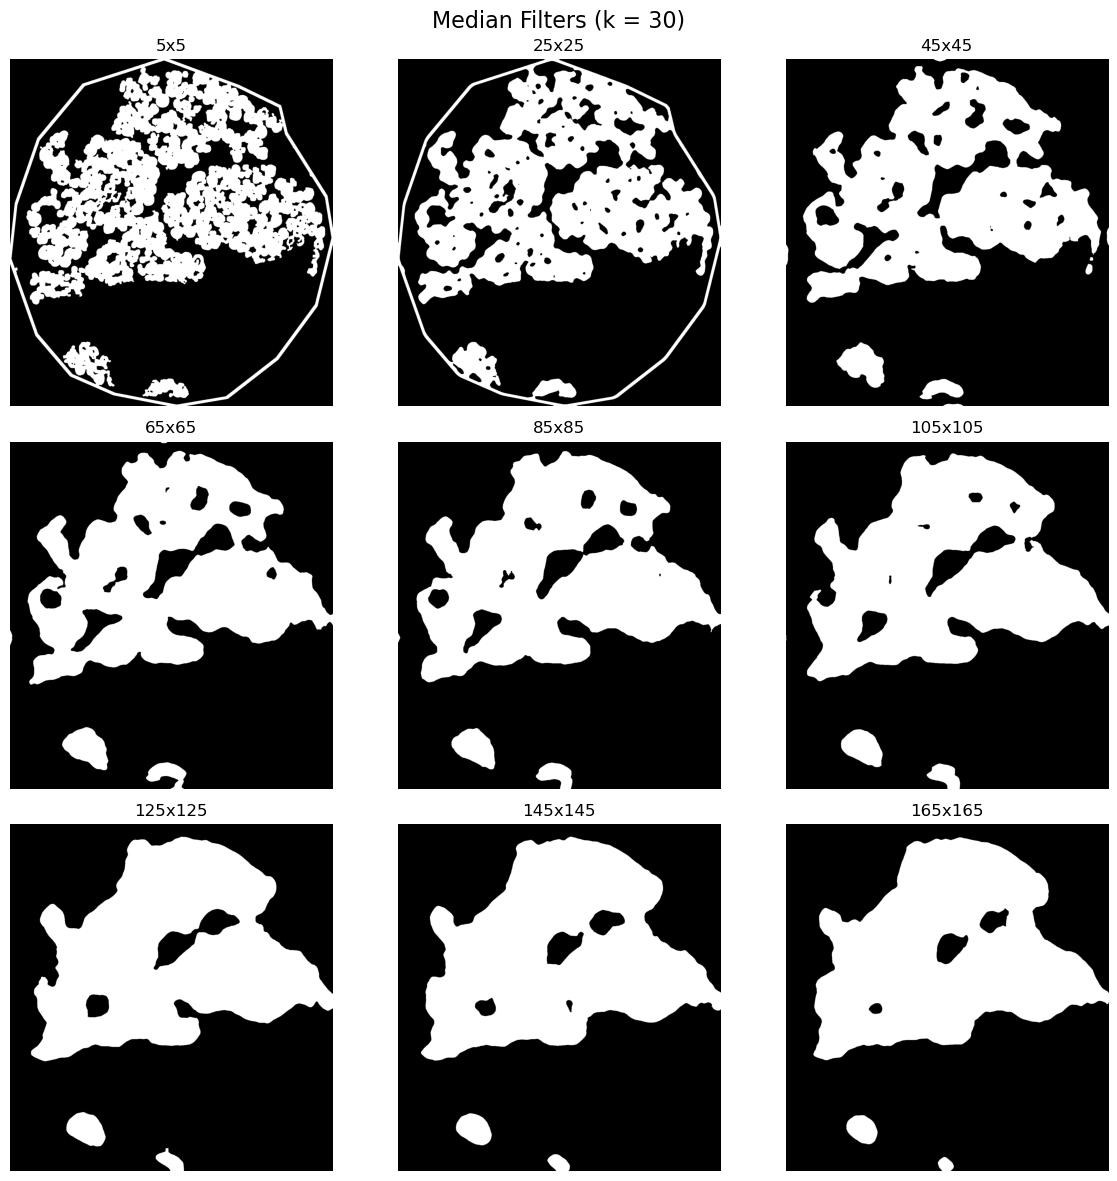

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from collections import deque

# -----------------------------
# 1. Load grayscale image
# -----------------------------
# 👉 CHANGE THIS PATH
image_path = r"C:\Users\3kp05\Downloads\blur_maps_set2_Image_01_20x_bf_05_all\4\blur_map_7x7.png"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found. Check path.")

h, w = img.shape

# -----------------------------
# 2. Condition function
# -----------------------------
def has_nonzero_neighbor(img, x, y):
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < h and 0 <= ny < w:
                if img[nx, ny] > 0:
                    return True
    return False


# -----------------------------
# 3. Multi-source clustering
# -----------------------------
def multi_source_clustering(img, seeds):
    labels = np.zeros((h, w), dtype=int)
    queue = deque()

    # Initialize seeds
    for i, (x, y) in enumerate(seeds):
        labels[x, y] = i + 1
        queue.append((x, y, i + 1))

    while queue:
        x, y, cid = queue.popleft()

        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy

                if 0 <= nx < h and 0 <= ny < w:
                    if labels[nx, ny] == 0:
                        if img[nx, ny] > 0 or has_nonzero_neighbor(img, nx, ny):
                            labels[nx, ny] = cid
                            queue.append((nx, ny, cid))

    return labels


# -----------------------------
# 4. Run for different k values
# -----------------------------
k_values = [23,27,30]  # you can change this

nonzero_pixels = list(zip(*np.where(img > 0)))

if len(nonzero_pixels) == 0:
    raise ValueError("No non-zero pixels in image.")

results = {}

for k in k_values:
    seeds = random.sample(nonzero_pixels, min(k, len(nonzero_pixels)))
    labels = multi_source_clustering(img, seeds)
    results[k] = labels


# -----------------------------
# 5. Plot results
# -----------------------------
for k in k_values:
    plt.figure()
    plt.title(f"Clusters with k = {k}")
    plt.imshow(results[k])
    plt.colorbar()
    plt.axis("off")
    plt.show()

# -----------------------------
# 6. Binary + Multiple Median Filters Visualization
# -----------------------------
for k in k_values:
    labels = results[k]

    # Convert to binary image
    binary = np.zeros_like(labels, dtype=np.uint8)
    binary[labels > 0] = 255

    # Kernel sizes (odd only)
    kernel_sizes = list(range(5, 166, 20))  # 5, 15, 25, ..., 165

    # Layout (2 or 3 rows)
    n = len(kernel_sizes)
    rows = 3
    cols = int(np.ceil(n / rows))

    plt.figure(figsize=(4 * cols, 4 * rows))
    plt.suptitle(f"Median Filters (k = {k})", fontsize=16)

    for i, ks in enumerate(kernel_sizes):
        median = cv2.medianBlur(binary, ks)

        plt.subplot(rows, cols, i + 1)
        plt.title(f"{ks}x{ks}")
        plt.imshow(median, cmap='gray')
        plt.axis("off")

    plt.tight_layout()
    plt.show()


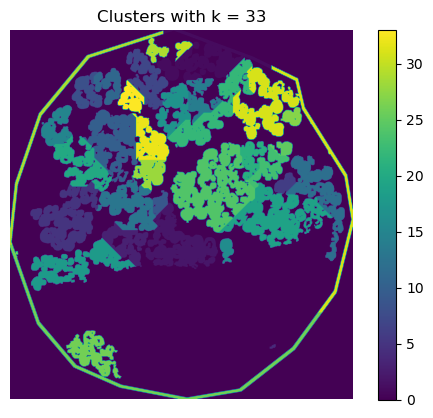

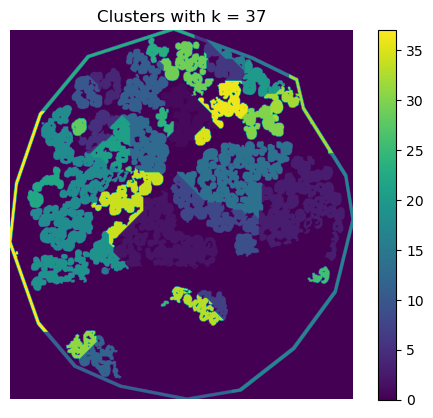

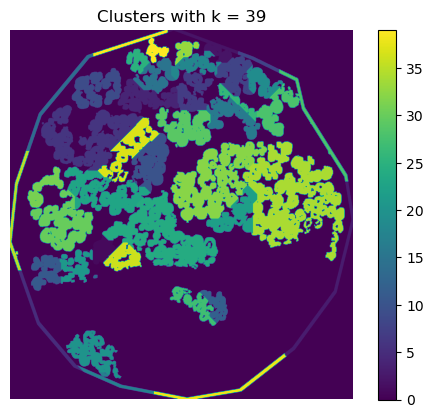

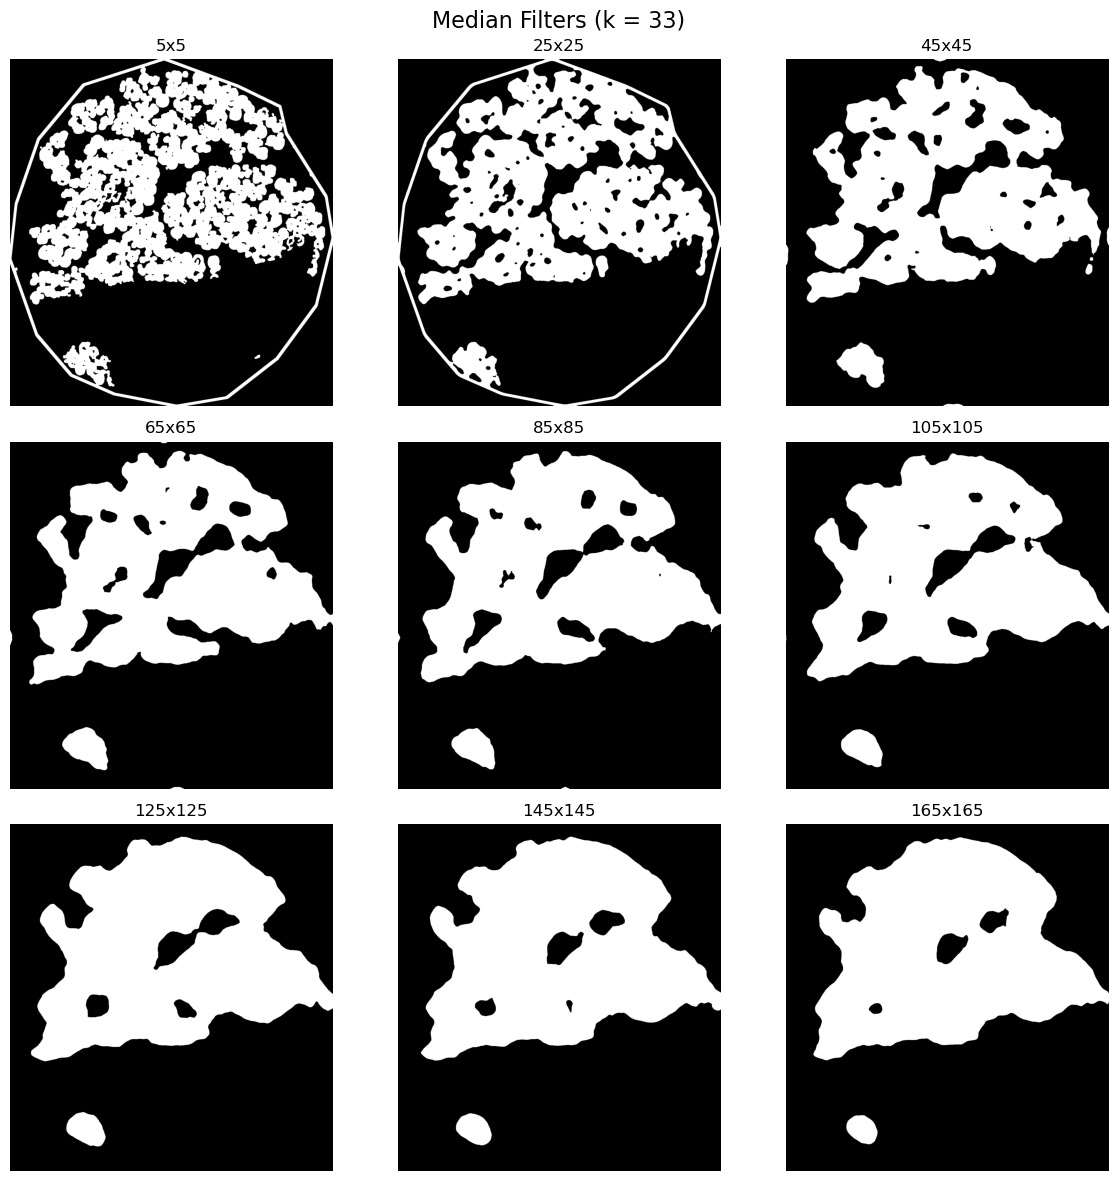

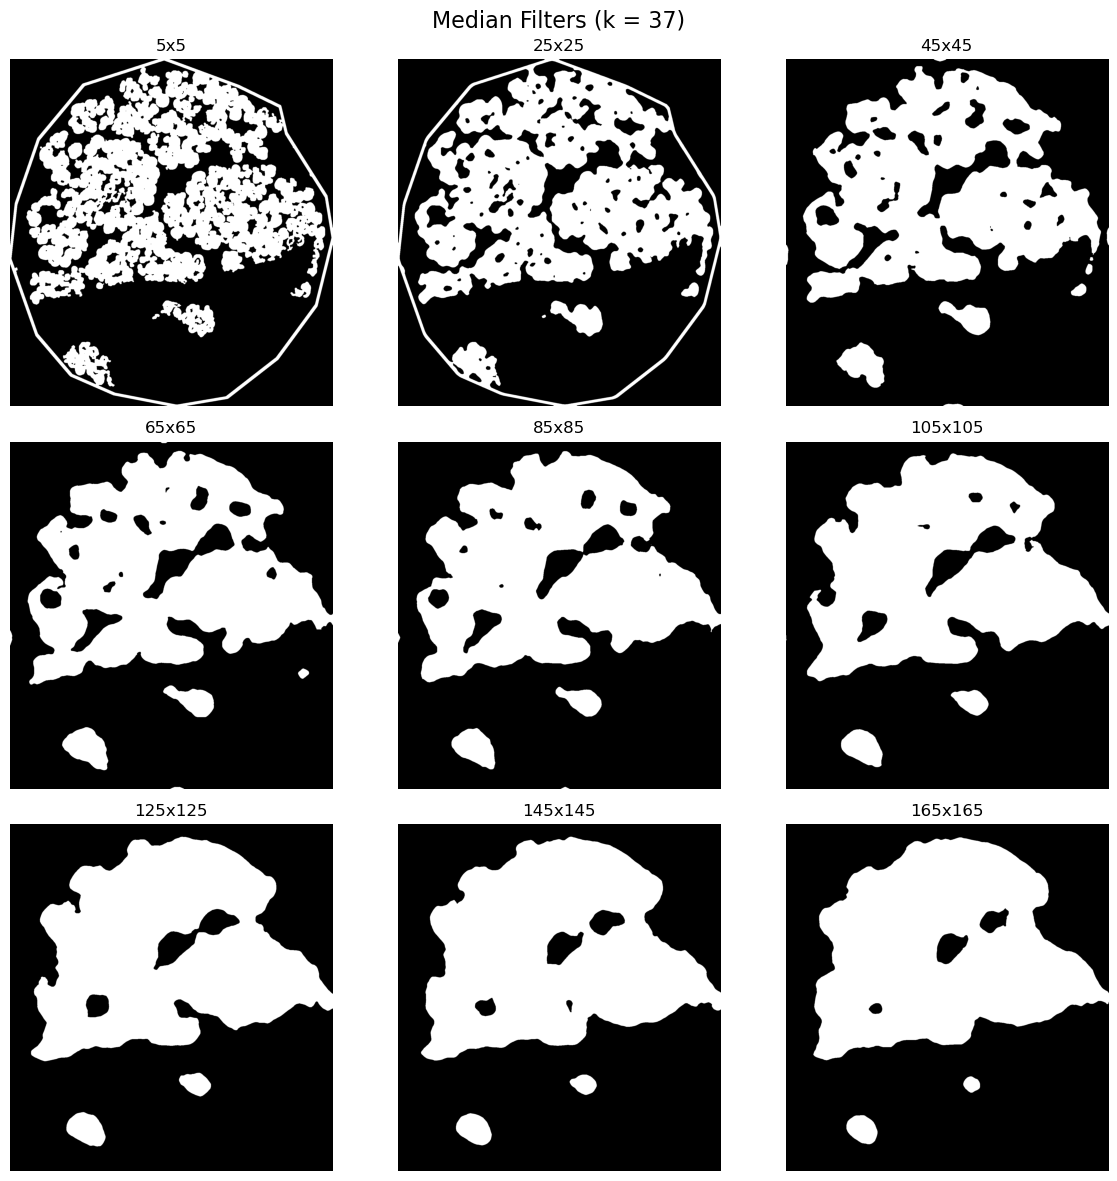

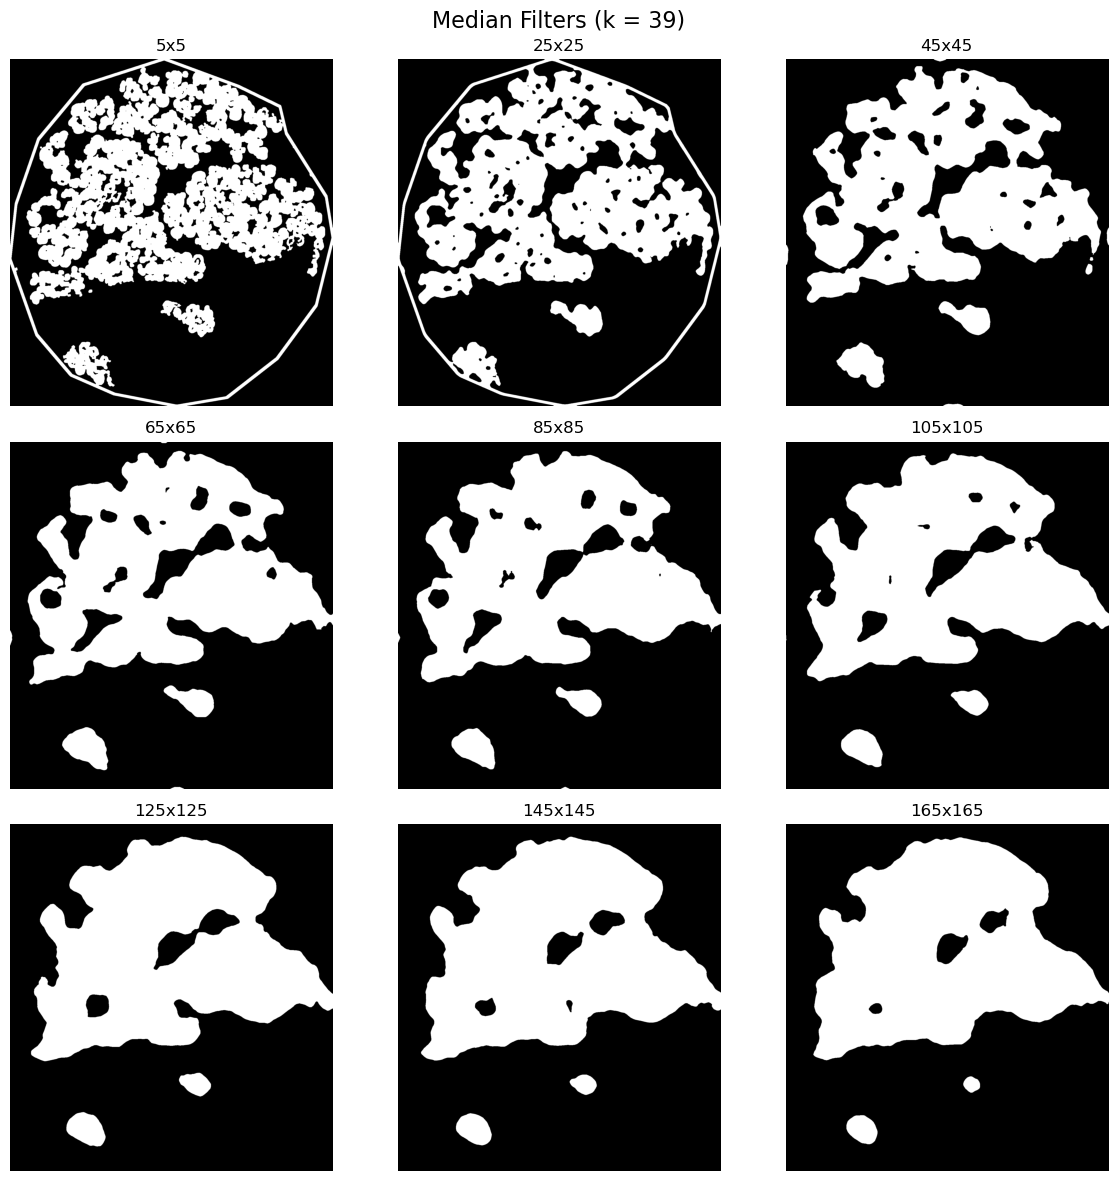

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from collections import deque

# -----------------------------
# 1. Load grayscale image
# -----------------------------
# 👉 CHANGE THIS PATH
image_path = r"C:\Users\3kp05\Downloads\blur_maps_set2_Image_01_20x_bf_05_all\4\blur_map_7x7.png"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found. Check path.")

h, w = img.shape

# -----------------------------
# 2. Condition function
# -----------------------------
def has_nonzero_neighbor(img, x, y):
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < h and 0 <= ny < w:
                if img[nx, ny] > 0:
                    return True
    return False


# -----------------------------
# 3. Multi-source clustering
# -----------------------------
def multi_source_clustering(img, seeds):
    labels = np.zeros((h, w), dtype=int)
    queue = deque()

    # Initialize seeds
    for i, (x, y) in enumerate(seeds):
        labels[x, y] = i + 1
        queue.append((x, y, i + 1))

    while queue:
        x, y, cid = queue.popleft()

        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy

                if 0 <= nx < h and 0 <= ny < w:
                    if labels[nx, ny] == 0:
                        if img[nx, ny] > 0 or has_nonzero_neighbor(img, nx, ny):
                            labels[nx, ny] = cid
                            queue.append((nx, ny, cid))

    return labels


# -----------------------------
# 4. Run for different k values
# -----------------------------
k_values = [33,37,39]  # you can change this

nonzero_pixels = list(zip(*np.where(img > 0)))

if len(nonzero_pixels) == 0:
    raise ValueError("No non-zero pixels in image.")

results = {}

for k in k_values:
    seeds = random.sample(nonzero_pixels, min(k, len(nonzero_pixels)))
    labels = multi_source_clustering(img, seeds)
    results[k] = labels


# -----------------------------
# 5. Plot results
# -----------------------------
for k in k_values:
    plt.figure()
    plt.title(f"Clusters with k = {k}")
    plt.imshow(results[k])
    plt.colorbar()
    plt.axis("off")
    plt.show()

# -----------------------------
# 6. Binary + Multiple Median Filters Visualization
# -----------------------------
for k in k_values:
    labels = results[k]

    # Convert to binary image
    binary = np.zeros_like(labels, dtype=np.uint8)
    binary[labels > 0] = 255

    # Kernel sizes (odd only)
    kernel_sizes = list(range(5, 166, 20))  # 5, 15, 25, ..., 165

    # Layout (2 or 3 rows)
    n = len(kernel_sizes)
    rows = 3
    cols = int(np.ceil(n / rows))

    plt.figure(figsize=(4 * cols, 4 * rows))
    plt.suptitle(f"Median Filters (k = {k})", fontsize=16)

    for i, ks in enumerate(kernel_sizes):
        median = cv2.medianBlur(binary, ks)

        plt.subplot(rows, cols, i + 1)
        plt.title(f"{ks}x{ks}")
        plt.imshow(median, cmap='gray')
        plt.axis("off")

    plt.tight_layout()
    plt.show()


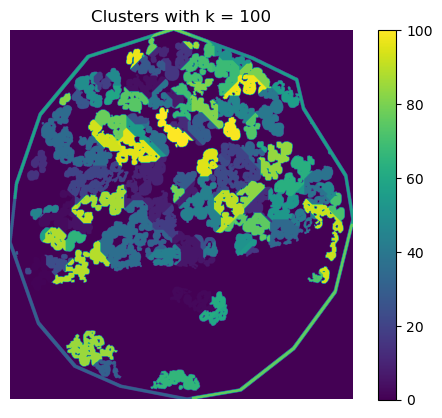

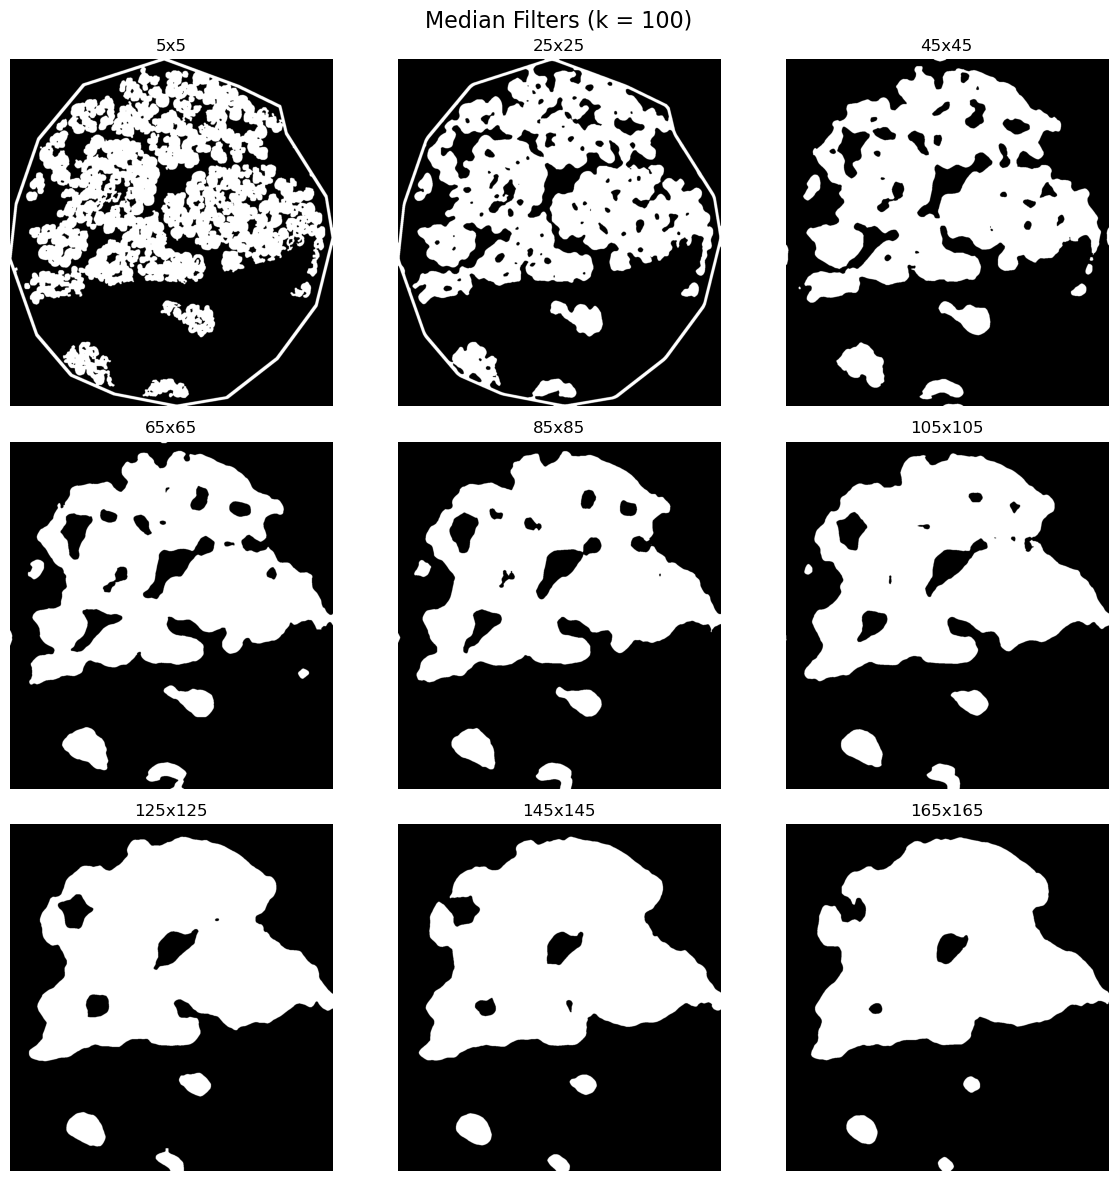

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from collections import deque

# -----------------------------
# 1. Load grayscale image
# -----------------------------
# 👉 CHANGE THIS PATH
image_path = r"C:\Users\3kp05\Downloads\blur_maps_set2_Image_01_20x_bf_05_all\4\blur_map_7x7.png"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found. Check path.")

h, w = img.shape

# -----------------------------
# 2. Condition function
# -----------------------------
def has_nonzero_neighbor(img, x, y):
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < h and 0 <= ny < w:
                if img[nx, ny] > 0:
                    return True
    return False


# -----------------------------
# 3. Multi-source clustering
# -----------------------------
def multi_source_clustering(img, seeds):
    labels = np.zeros((h, w), dtype=int)
    queue = deque()

    # Initialize seeds
    for i, (x, y) in enumerate(seeds):
        labels[x, y] = i + 1
        queue.append((x, y, i + 1))

    while queue:
        x, y, cid = queue.popleft()

        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy

                if 0 <= nx < h and 0 <= ny < w:
                    if labels[nx, ny] == 0:
                        if img[nx, ny] > 0 or has_nonzero_neighbor(img, nx, ny):
                            labels[nx, ny] = cid
                            queue.append((nx, ny, cid))

    return labels


# -----------------------------
# 4. Run for different k values
# -----------------------------
k_values = [100]  # you can change this

nonzero_pixels = list(zip(*np.where(img > 0)))

if len(nonzero_pixels) == 0:
    raise ValueError("No non-zero pixels in image.")

results = {}

for k in k_values:
    seeds = random.sample(nonzero_pixels, min(k, len(nonzero_pixels)))
    labels = multi_source_clustering(img, seeds)
    results[k] = labels


# -----------------------------
# 5. Plot results
# -----------------------------
for k in k_values:
    plt.figure()
    plt.title(f"Clusters with k = {k}")
    plt.imshow(results[k])
    plt.colorbar()
    plt.axis("off")
    plt.show()

# -----------------------------
# 6. Binary + Multiple Median Filters Visualization
# -----------------------------
for k in k_values:
    labels = results[k]

    # Convert to binary image
    binary = np.zeros_like(labels, dtype=np.uint8)
    binary[labels > 0] = 255

    # Kernel sizes (odd only)
    kernel_sizes = list(range(5, 166, 20))  # 5, 15, 25, ..., 165

    # Layout (2 or 3 rows)
    n = len(kernel_sizes)
    rows = 3
    cols = int(np.ceil(n / rows))

    plt.figure(figsize=(4 * cols, 4 * rows))
    plt.suptitle(f"Median Filters (k = {k})", fontsize=16)

    for i, ks in enumerate(kernel_sizes):
        median = cv2.medianBlur(binary, ks)

        plt.subplot(rows, cols, i + 1)
        plt.title(f"{ks}x{ks}")
        plt.imshow(median, cmap='gray')
        plt.axis("off")

    plt.tight_layout()
    plt.show()


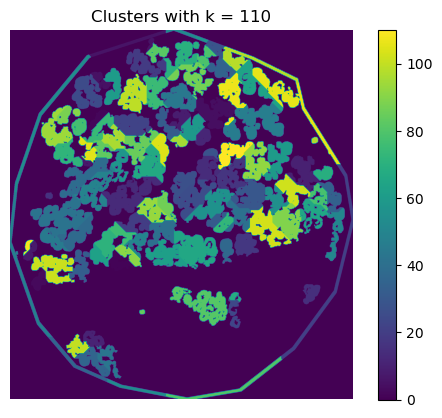

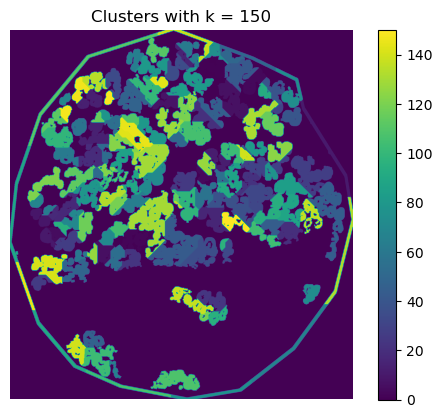

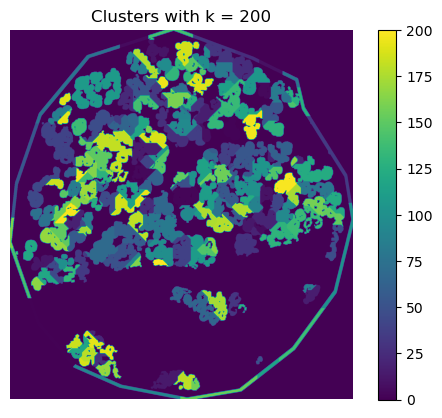

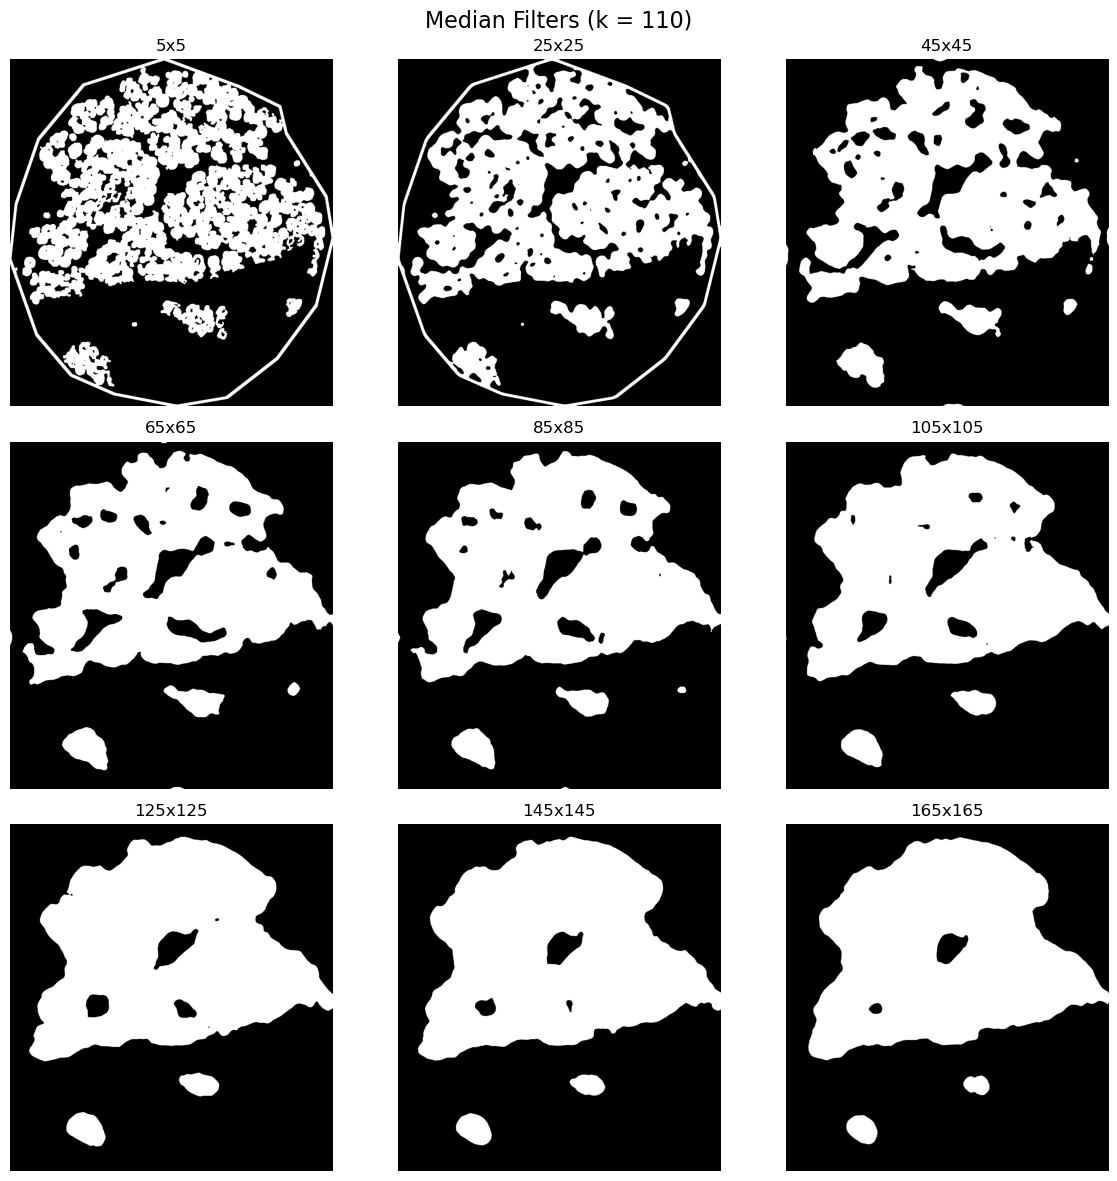

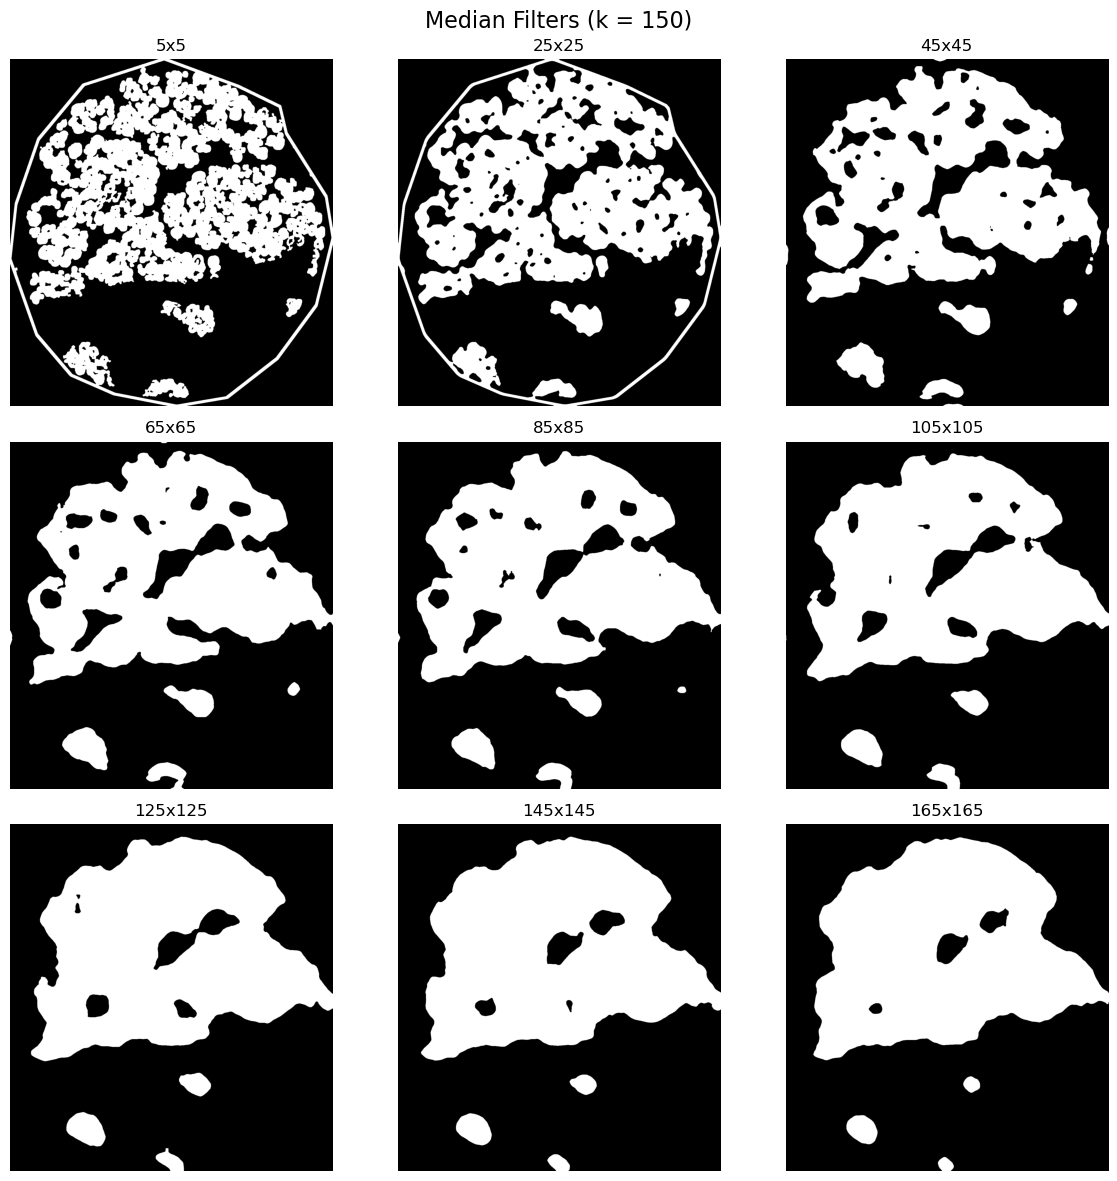

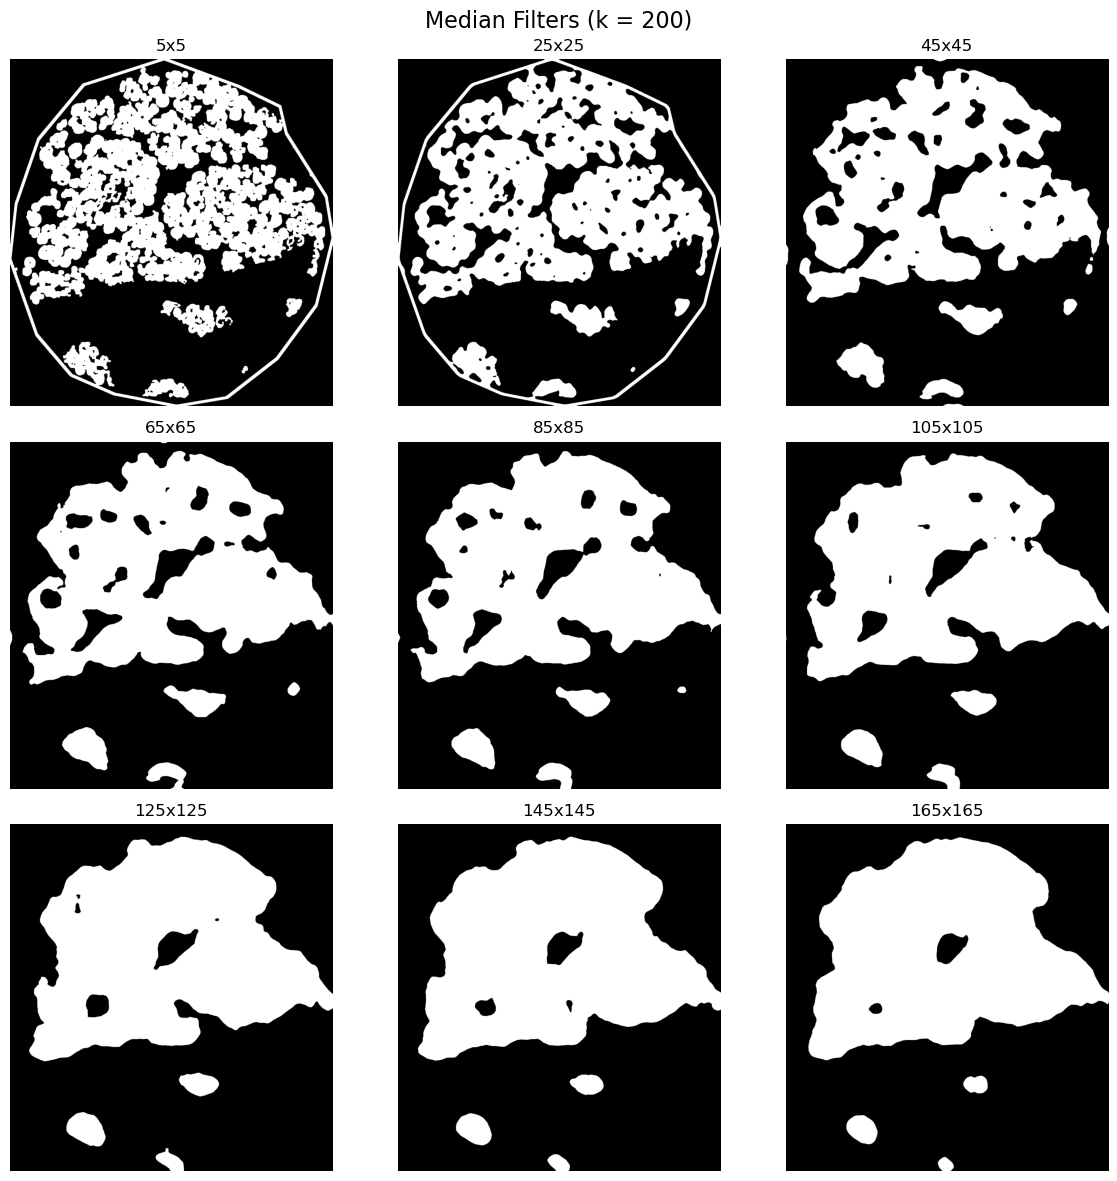

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from collections import deque

# -----------------------------
# 1. Load grayscale image
# -----------------------------
# 👉 CHANGE THIS PATH
image_path = r"C:\Users\3kp05\Downloads\blur_maps_set2_Image_01_20x_bf_05_all\4\blur_map_7x7.png"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found. Check path.")

h, w = img.shape

# -----------------------------
# 2. Condition function
# -----------------------------
def has_nonzero_neighbor(img, x, y):
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < h and 0 <= ny < w:
                if img[nx, ny] > 0:
                    return True
    return False


# -----------------------------
# 3. Multi-source clustering
# -----------------------------
def multi_source_clustering(img, seeds):
    labels = np.zeros((h, w), dtype=int)
    queue = deque()

    # Initialize seeds
    for i, (x, y) in enumerate(seeds):
        labels[x, y] = i + 1
        queue.append((x, y, i + 1))

    while queue:
        x, y, cid = queue.popleft()

        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy

                if 0 <= nx < h and 0 <= ny < w:
                    if labels[nx, ny] == 0:
                        if img[nx, ny] > 0 or has_nonzero_neighbor(img, nx, ny):
                            labels[nx, ny] = cid
                            queue.append((nx, ny, cid))

    return labels


# -----------------------------
# 4. Run for different k values
# -----------------------------
k_values = [110, 150, 200]  # you can change this

nonzero_pixels = list(zip(*np.where(img > 0)))

if len(nonzero_pixels) == 0:
    raise ValueError("No non-zero pixels in image.")

results = {}

for k in k_values:
    seeds = random.sample(nonzero_pixels, min(k, len(nonzero_pixels)))
    labels = multi_source_clustering(img, seeds)
    results[k] = labels


# -----------------------------
# 5. Plot results
# -----------------------------
for k in k_values:
    plt.figure()
    plt.title(f"Clusters with k = {k}")
    plt.imshow(results[k])
    plt.colorbar()
    plt.axis("off")
    plt.show()

# -----------------------------
# 6. Binary + Multiple Median Filters Visualization
# -----------------------------
for k in k_values:
    labels = results[k]

    # Convert to binary image
    binary = np.zeros_like(labels, dtype=np.uint8)
    binary[labels > 0] = 255

    # Kernel sizes (odd only)
    kernel_sizes = list(range(5, 166, 20))  # 5, 15, 25, ..., 165

    # Layout (2 or 3 rows)
    n = len(kernel_sizes)
    rows = 3
    cols = int(np.ceil(n / rows))

    plt.figure(figsize=(4 * cols, 4 * rows))
    plt.suptitle(f"Median Filters (k = {k})", fontsize=16)

    for i, ks in enumerate(kernel_sizes):
        median = cv2.medianBlur(binary, ks)

        plt.subplot(rows, cols, i + 1)
        plt.title(f"{ks}x{ks}")
        plt.imshow(median, cmap='gray')
        plt.axis("off")

    plt.tight_layout()
    plt.show()
